## CHICAGO CRIME DATA ANALYSIS
## Crime analysis of the city of Chicago from 2025 - 2026 based on the 250,000 most recent records

Data analysis pipeline
- 1. Data Loading from the API
- 2. Exploratory Data Analysis
- 3. Data Cleaning
- 4. SQL queries using SQL alchemy
- 5. Visualizations with Matplotlib and SEaborn
- 6. Mini Dashboard using tableau
- 7. Insights and recommendations

# 1. Imports and Setup

In [4]:
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pandas as pd

# 2. Data Loading
- The data is sourced from the City of Chicago's website. It contains 250,000 reported crime incidents across 22 columns .

In [5]:
import pandas as pd
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=250000"
df = pd.read_csv(url)

In [6]:
df.to_csv('chicago_crime_data.csv', index = False)
df.head(2)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14184518,JK239006,2026-05-02T00:00:00.000,003XX E 119TH ST,0460,BATTERY,SIMPLE,APARTMENT,False,False,...,9.0,53.0,08B,1180172.0,1826116.0,2026,2026-05-09T15:42:04.000,41.678124,-87.616141,"\n, \n(41.678124496, -87.616140767)"
1,14188590,JK244045,2026-05-02T00:00:00.000,036XX S HERMITAGE AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,RESIDENCE,False,False,...,12.0,59.0,02,1165283.0,1880467.0,2026,2026-05-09T15:42:04.000,41.827599,-87.669104,"\n, \n(41.827598549, -87.669103891)"


In [7]:
df = pd.read_csv('chicago_crime_data.csv')
df.head(5)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14184518,JK239006,2026-05-02T00:00:00.000,003XX E 119TH ST,0460,BATTERY,SIMPLE,APARTMENT,False,False,...,9.0,53.0,08B,1180172.0,1826116.0,2026,2026-05-09T15:42:04.000,41.678124,-87.616141,"\n, \n(41.678124496, -87.616140767)"
1,14188590,JK244045,2026-05-02T00:00:00.000,036XX S HERMITAGE AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,RESIDENCE,False,False,...,12.0,59.0,02,1165283.0,1880467.0,2026,2026-05-09T15:42:04.000,41.827599,-87.669104,"\n, \n(41.827598549, -87.669103891)"
2,14188867,JK244620,2026-05-02T00:00:00.000,003XX E 46TH ST,0890,THEFT,FROM BUILDING,APARTMENT,False,False,...,3.0,38.0,06,1179058.0,1874589.0,2026,2026-05-09T15:42:04.000,41.811165,-87.618745,"\n, \n(41.811165468, -87.618744949)"
3,14186757,JK242103,2026-05-02T00:00:00.000,064XX N LEAVITT ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,50.0,2.0,14,1160469.0,1942767.0,2026,2026-05-09T15:42:04.000,41.998655,-87.685038,"\n, \n(41.998655163, -87.685038166)"
4,14186419,JK241358,2026-05-02T00:00:00.000,024XX E 77TH ST,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,STREET,False,False,...,7.0,43.0,02,1193713.0,1854381.0,2026,2026-05-09T15:42:04.000,41.755366,-87.565654,"\n, \n(41.75536643, -87.565654201)"


In [8]:
print (df.shape)
print(df.head)
print(df.dtypes)

(250000, 22)
<bound method NDFrame.head of               id case_number                     date                  block  \
0       14184518    JK239006  2026-05-02T00:00:00.000       003XX E 119TH ST   
1       14188590    JK244045  2026-05-02T00:00:00.000  036XX S HERMITAGE AVE   
2       14188867    JK244620  2026-05-02T00:00:00.000        003XX E 46TH ST   
3       14186757    JK242103  2026-05-02T00:00:00.000     064XX N LEAVITT ST   
4       14186419    JK241358  2026-05-02T00:00:00.000        024XX E 77TH ST   
...          ...         ...                      ...                    ...   
249995  13806023    JJ218126  2025-04-06T13:51:00.000        0000X E 90TH ST   
249996  13797673    JJ208270  2025-04-06T13:45:00.000        037XX W 57TH PL   
249997  13797634    JJ208307  2025-04-06T13:41:00.000        027XX W 65TH ST   
249998  13850377    JJ272234  2025-04-06T13:40:00.000     005XX W BELDEN AVE   
249999  13797664    JJ208276  2025-04-06T13:31:00.000        0000X E 71ST ST 

# 3. Initial Exploratory Data Analysis
- Before cleaning we will examine the raw data to understand it. (Summary Statistics, missing values,distribution of crime types, location descriptions,)

In [9]:
#summary statistics 
df.describe()

,id,beat,district,ward,community_area,x_coordinate,y_coordinate,year,latitude,longitude
count,2.500000e+05,250000.000000,250000.000000,249999.000000,249991.000000,2.498970e+05,2.498970e+05,250000.000000,249897.000000,249897.000000
mean,1.396694e+07,1142.909728,11.198560,23.020216,36.235388,1.165772e+06,1.887208e+06,2025.284912,41.846070,-87.667159
std,6.080424e+05,708.130482,7.075774,13.950593,21.475158,1.622396e+04,3.131356e+04,0.451373,0.086110,0.059076
min,2.865700e+04,111.000000,1.000000,1.000000,1.000000,1.094182e+06,1.813909e+06,2025.000000,41.644608,-87.928903
25%,1.389613e+07,524.000000,5.000000,10.000000,22.000000,1.154571e+06,1.860313e+06,2025.000000,41.772182,-87.707926
50%,1.399192e+07,1032.000000,10.000000,23.000000,32.000000,1.167740e+06,1.893589e+06,2025.000000,41.863665,-87.659809
75%,1.408866e+07,1731.000000,17.000000,34.000000,53.000000,1.176929e+06,1.909975e+06,2026.000000,41.908541,-87.626222
max,1.419174e+07,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951495e+06,2026.000000,42.022548,-87.524529


In [10]:
#null values
null_total = df.isnull().sum()
null_total

id                         0
case_number                0
date                       0
block                      0
iucr                       0
primary_type               0
description                0
location_description    1204
arrest                     0
domestic                   0
beat                       0
district                   0
ward                       1
community_area             9
fbi_code                   0
x_coordinate             103
y_coordinate             103
year                       0
updated_on                 0
latitude                 103
longitude                103
location                 103
dtype: int64

In [11]:
#distribution of primary crimes
primary_crime_total = df['primary_type'].value_counts()
primary_crime_total

primary_type
THEFT                                57106
BATTERY                              45569
CRIMINAL DAMAGE                      28044
ASSAULT                              22914
MOTOR VEHICLE THEFT                  18863
OTHER OFFENSE                        17223
DECEPTIVE PRACTICE                   14828
BURGLARY                             11836
NARCOTICS                             7263
ROBBERY                               5735
CRIMINAL TRESPASS                     5732
WEAPONS VIOLATION                     5451
CRIMINAL SEXUAL ASSAULT               1754
OFFENSE INVOLVING CHILDREN            1643
SEX OFFENSE                           1390
PUBLIC PEACE VIOLATION                1152
INTERFERENCE WITH PUBLIC OFFICER       974
STALKING                               629
HOMICIDE                               461
ARSON                                  387
CONCEALED CARRY LICENSE VIOLATION      244
LIQUOR LAW VIOLATION                   202
PROSTITUTION                           19

In [12]:
#year distributions
year_dist = df['year'].value_counts().sort_index()
year_dist

year
2025    178772
2026     71228
Name: count, dtype: int64

In [13]:
arrest_rate = df['arrest'].mean()
print(f"{arrest_rate:.2%}")

15.38%


In [14]:
domestic_crime_rate = df['domestic'].mean()
print(f"{domestic_crime_rate:.2%}")

19.12%


In [15]:
top_locations = df['location_description'].value_counts().head(10)
top_locations

location_description
STREET                                    67248
APARTMENT                                 48770
RESIDENCE                                 29167
SIDEWALK                                  12577
PARKING LOT / GARAGE (NON RESIDENTIAL)     9180
SMALL RETAIL STORE                         9096
DEPARTMENT STORE                           5913
RESTAURANT                                 5556
ALLEY                                      5358
OTHER (SPECIFY)                            4477
Name: count, dtype: int64

# AND .Data Cleaning
- Dealing with missing values;
1. Date parsing
2. Duplicate rows
3. Text standardization
4. Location description column
5. Handling null values
6. Feature engineering

In [16]:
# 1. Date parsing (from string to datetime)
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype
df['hour'] = df['date'].dt.hour
df['day_name'] = df['date'].dt.day_name()
print(df['date'].dtype)

df['date'].head(3).tolist()

datetime64[ns]


[Timestamp('2026-05-02 00:00:00'),
 Timestamp('2026-05-02 00:00:00'),
 Timestamp('2026-05-02 00:00:00')]

In [17]:
# 2. Duplicate records
df.duplicated().sum()

0

In [18]:
# 3. Text standardization
text_cols = ['primary_type', 'description', 'location_description', 'block', 'fbi_code']

for col in text_cols:
    before_unique = df[col].nunique()
    df[col] = df[col].str.strip().str.upper()
    after_unique = df[col].nunique()
    print(f'{col}: unique values {before_unique} -> {after_unique}')
    

primary_type: unique values 31 -> 31
description: unique values 312 -> 312
location_description: unique values 130 -> 130
block: unique values 28358 -> 26914
fbi_code: unique values 26 -> 26


In [19]:
# 4. Location description column
consolidations = {
    'OTHER (SPECIFY)': 'OTHER',
    'OTHER COMMERCIAL TRANSPORTATION': 'OTHER TRANSPORTATION',
}

before_unique = df['location_description'].nunique()
df['location_description'] = df['location_description'].replace(consolidations)
after_unique = df['location_description'].nunique()

print(f'location_description unique values: {before_unique} -> {after_unique}')
print(f'Rows affected by consolidation: {df["location_description"].isin(consolidations.values()).sum():,}')


location_description unique values: 130 -> 130
Rows affected by consolidation: 4,563


In [20]:
# null values handling
df['location_description'] = df['location_description'].fillna('UNKNOWN')
df['ward'] = df['ward'].fillna(df['ward'].median())
df['community_area'] = df['community_area'].fillna(df['community_area'].median())

In [21]:
df.isnull().sum()

id                        0
case_number               0
date                      0
block                     0
iucr                      0
primary_type              0
description               0
location_description      0
arrest                    0
domestic                  0
beat                      0
district                  0
ward                      0
community_area            0
fbi_code                  0
x_coordinate            103
y_coordinate            103
year                      0
updated_on                0
latitude                103
longitude               103
location                103
hour                      0
day_name                  0
dtype: int64

In [22]:
# 6. Feature engineering with date time
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['month'] = df['date'].dt.month
df['hour'] = df['date'].dt.hour
df['day_of_week'] = pd.Categorical(
    df['date'].dt.day_name(),
    categories=day_order,
    ordered=True
)
df['quarter'] = df['date'].dt.quarter
df['midnight_flag'] = df['hour'] == 0

df['date'].dtype

dtype('<M8[ns]')

In [23]:
df.to_csv('chicago_data_cleaned.csv', index=False)

## 4. DATA ANALYSIS WITH SQL

# We'll load the cleaned DataFrame into sqlalchemy

In [24]:
df2 = pd.read_csv('chicago_data_cleaned.csv')
df2.head(2)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,latitude,longitude,location,hour,day_name,month,day_of_week,quarter,midnight_flag
0,14184518,JK239006,2026-05-02 00:00:00,003XX E 119TH ST,0460,BATTERY,SIMPLE,APARTMENT,False,False,...,2026-05-09T15:42:04.000,41.678124,-87.616141,"\n, \n(41.678124496, -87.616140767)",0,Saturday,5,Saturday,2,True
1,14188590,JK244045,2026-05-02 00:00:00,036XX S HERMITAGE AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,RESIDENCE,False,False,...,2026-05-09T15:42:04.000,41.827599,-87.669104,"\n, \n(41.827598549, -87.669103891)",0,Saturday,5,Saturday,2,True


In [25]:
engine = create_engine('sqlite:///chicago_crime.db')
df2.to_sql('chicago_crimes', engine, index=False, if_exists='replace')


250000

In [26]:
count = pd.read_sql('SELECT COUNT(*) as total FROM chicago_crimes', engine)['total']
count

0    250000
Name: total, dtype: int64

# Queries
- Top 10 crimes by volume with percentage
- Arrest rate by crime type
- Domestic vs non-domestic comparisons
- Crime volume vs arrest rate by police district
- Monthly crime counts
- Top 10 locations type by incident count

In [27]:
# Query 1: Top 10 crime types by volume with percentage share
q1 = pd.read_sql("""
    SELECT
        primary_type,
        COUNT(*) AS total_incidents,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM chicago_crimes), 2) AS pct_of_total
    FROM chicago_crimes
    GROUP BY primary_type
    ORDER BY total_incidents DESC
    LIMIT 10
""", engine)
print('Top 10 crime types:')
q1

Top 10 crime types:


,primary_type,total_incidents,pct_of_total
0,THEFT,57106,22.84
1,BATTERY,45569,18.23
2,CRIMINAL DAMAGE,28044,11.22
3,ASSAULT,22914,9.17
4,MOTOR VEHICLE THEFT,18863,7.55
5,OTHER OFFENSE,17223,6.89
6,DECEPTIVE PRACTICE,14828,5.93
7,BURGLARY,11836,4.73
8,NARCOTICS,7263,2.91
9,ROBBERY,5735,2.29


- Insights : The most committed crime is theft with a total of 57,074 incidents which is making 22.83% of all crimes commited in Chicago

In [28]:
# Query 2: Arrest rate by crime type (types with more than 1,000 incidents)
q2 = pd.read_sql("""
    SELECT
        primary_type,
        COUNT(*) AS total_incidents,
        SUM(CASE WHEN arrest = 1 THEN 1 ELSE 0 END) AS total_arrests,
        ROUND(
            100.0 * SUM(CASE WHEN arrest = 1 THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS arrest_rate_pct
    FROM chicago_crimes
    GROUP BY primary_type
    HAVING total_incidents > 1000
    ORDER BY arrest_rate_pct DESC
    LIMIT 10
""", engine)
print('Arrest rate by crime type:')
q2

Arrest rate by crime type:


,primary_type,total_incidents,total_arrests,arrest_rate_pct
0,NARCOTICS,7263,6835,94.11
1,WEAPONS VIOLATION,5451,4200,77.05
2,PUBLIC PEACE VIOLATION,1152,591,51.30
3,CRIMINAL TRESPASS,5732,1842,32.14
4,BATTERY,45569,8616,18.91
5,OTHER OFFENSE,17223,3122,18.13
6,ASSAULT,22914,2868,12.52
7,ROBBERY,5735,535,9.33
8,THEFT,57106,5049,8.84
9,SEX OFFENSE,1390,103,7.41


Insights : Narcotics has the highest arrest percentage, even though it has one of the lowest total incidents
- Sex offence crimes has the lowest arrest percentage with a total of 105 arrests out of 1388 total incidents.
- Theft has the highest total incidents yet a small arrest percentage of 8.84%

In [29]:
# Query 3: Domestic vs non-domestic crime breakdown
q3 = pd.read_sql("""
    SELECT
        CASE WHEN domestic = 1 THEN 'Domestic' ELSE 'Non-Domestic' END AS incident_type,
        COUNT(*) AS total,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM chicago_crimes), 2) AS pct
    FROM chicago_crimes
    GROUP BY domestic
""", engine)
print('Domestic vs Non-Domestic:')
q3

Domestic vs Non-Domestic:


,incident_type,total,pct
0,Non-Domestic,202201,80.88
1,Domestic,47799,19.12


Non- Domestic incidents make up most of the incident type with 80.86% of all incidents

In [30]:
# Query 4: Crime volume and arrest rate by police district
q4 = pd.read_sql("""
    SELECT
        district,
        COUNT(*) AS total_crimes,
        SUM(CASE WHEN arrest = 1 THEN 1 ELSE 0 END) AS total_arrests,
        ROUND(
            100.0 * SUM(CASE WHEN arrest = 1 THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS arrest_rate_pct
    FROM chicago_crimes
    GROUP BY district
    ORDER BY total_crimes DESC
    LIMIT 10
""", engine)
print('Top districts by crime volume:')
q4

Top districts by crime volume:


,district,total_crimes,total_arrests,arrest_rate_pct
0,12,16324,1583,9.70
1,8,15736,2298,14.60
2,1,14373,2518,17.52
3,6,14195,2003,14.11
4,18,13930,1943,13.95
5,2,13791,1506,10.92
6,3,13787,1959,14.21
7,4,13737,1737,12.64
8,19,13462,1206,8.96
9,11,13260,3615,27.26


Insights : The 12th  District has the most total crimes but with a low arrest rate as compared to the 11th district which has the lowest total crimes but with the highest arrest rate as compared to other districts

In [31]:
# Query 5: Monthly crime counts
q5 = pd.read_sql("""
    SELECT
        month,
        COUNT(*) AS incidents
    FROM chicago_crimes
    GROUP BY month
    ORDER BY incidents desc
""", engine)
print('Monthly crime counts:')
q5

Monthly crime counts:


,month,incidents
0,4,34592
1,7,22651
2,8,21323
3,6,21108
4,5,21087
5,10,20962
6,9,20330
7,3,18865
8,11,18393
9,12,17462


Insights : April has the most total incidents and February has the lowest total incidents

In [32]:
# Query 6: Top 10 location types by incident count
q6 = pd.read_sql("""
    SELECT
        location_description,
        COUNT(*) AS incidents
    FROM chicago_crimes
    GROUP BY location_description
    ORDER BY incidents DESC
    LIMIT 10
""", engine)
print('Top location types:')
q6

Top location types:


,location_description,incidents
0,STREET,67248
1,APARTMENT,48770
2,RESIDENCE,29167
3,SIDEWALK,12577
4,PARKING LOT / GARAGE (NON RESIDENTIAL),9180
5,SMALL RETAIL STORE,9096
6,DEPARTMENT STORE,5913
7,RESTAURANT,5556
8,ALLEY,5358
9,OTHER,4477


Insights : Most crime incidents happen in the street then followed by apartments

## 6. Visualizations
# Seven charts are produced using Matplotlib and seaborn

In [36]:
import seaborn as sns
import matplotlib.ticker as mticker

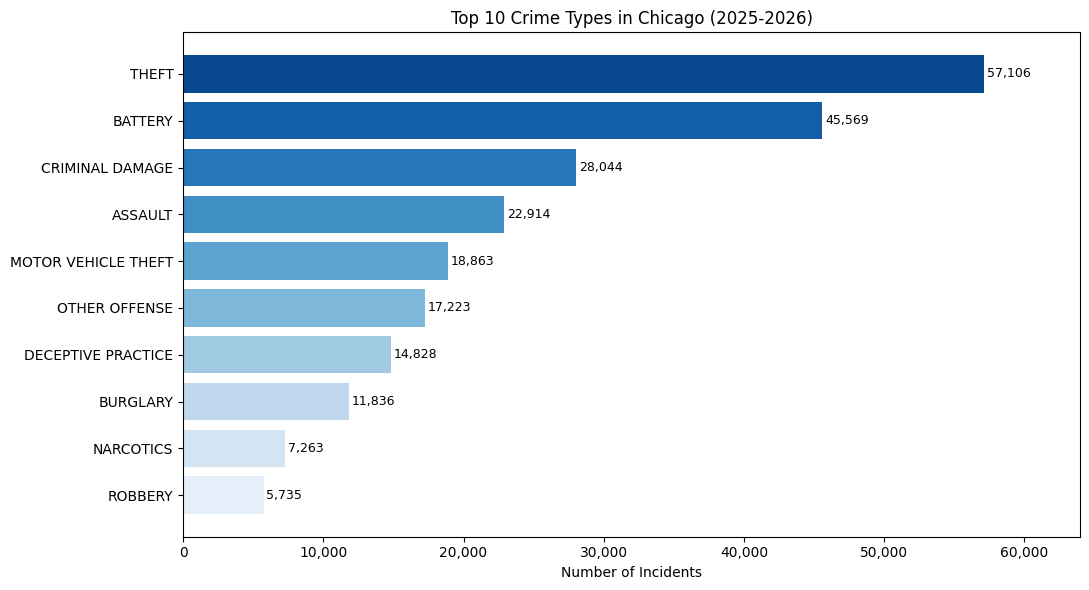

In [37]:
# Figure 1: Top 10 crime types by volume
top10 = df2['primary_type'].value_counts().head(10).reset_index()
top10.columns = ['primary_type', 'count']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top10['primary_type'][::-1],
    top10['count'][::-1],
    color=sns.color_palette('Blues', 10)
)
for bar, val in zip(bars, top10['count'][::-1]):
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        fontsize=9
    )
ax.set_xlabel('Number of Incidents')
ax.set_title('Top 10 Crime Types in Chicago (2025-2026)')
ax.set_xlim(0, top10['count'].max() * 1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig1_top_crime_types.png', dpi=150, bbox_inches='tight')
plt.show()

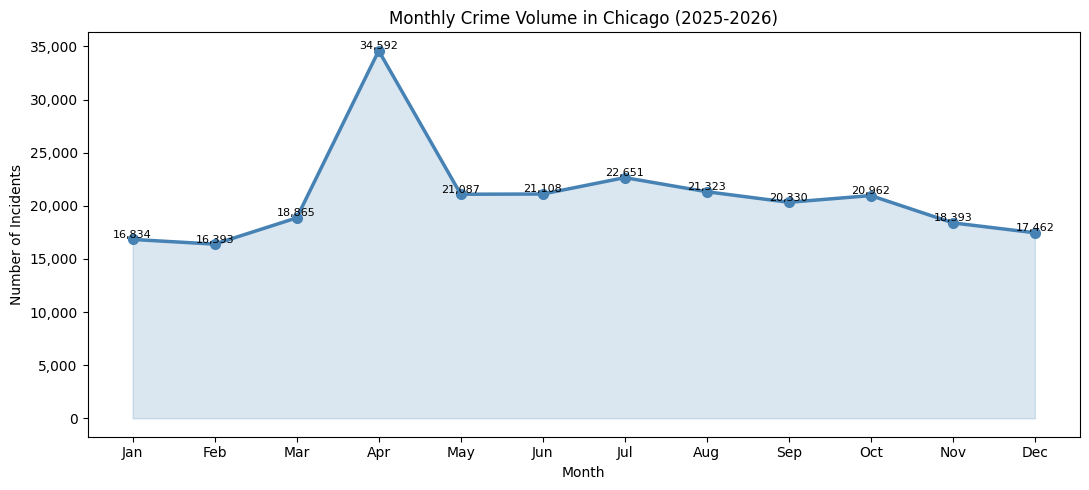

In [ ]:
# Figure 2: Monthly crime trend
monthly = df.groupby('month').size().reset_index(name='count')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x - 1])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    monthly['month_name'],
    monthly['count'],
    marker='o',
    color='steelblue',
    linewidth=2.5,
    markersize=7
)
ax.fill_between(monthly['month_name'], monthly['count'], alpha=0.2, color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Incidents')
ax.set_title('Monthly Crime Volume in Chicago (2025-2026)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, row in monthly.iterrows():
    ax.text(i, row['count'] + 150, f"{row['count']:,}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

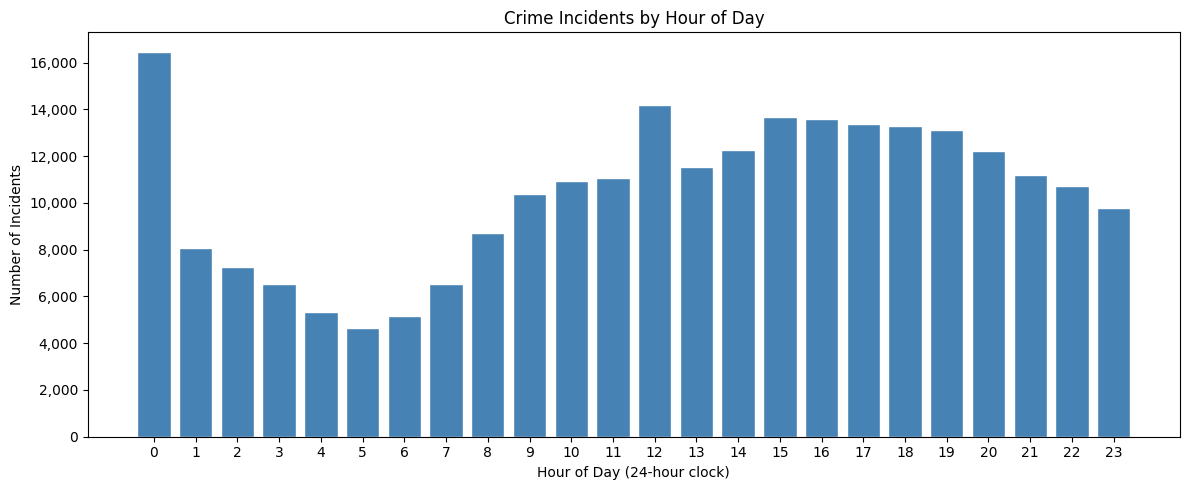

In [39]:
# Figure 3: Hourly distribution of crimes
# Midnight (hour 0) has the highest count, likely because unspecified times default to 00:00.
hourly = df.groupby('hour').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly['hour'], hourly['count'], color='steelblue', edgecolor='white')
ax.set_xlabel('Hour of Day (24-hour clock)')
ax.set_ylabel('Number of Incidents')
ax.set_title('Crime Incidents by Hour of Day')
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig3_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

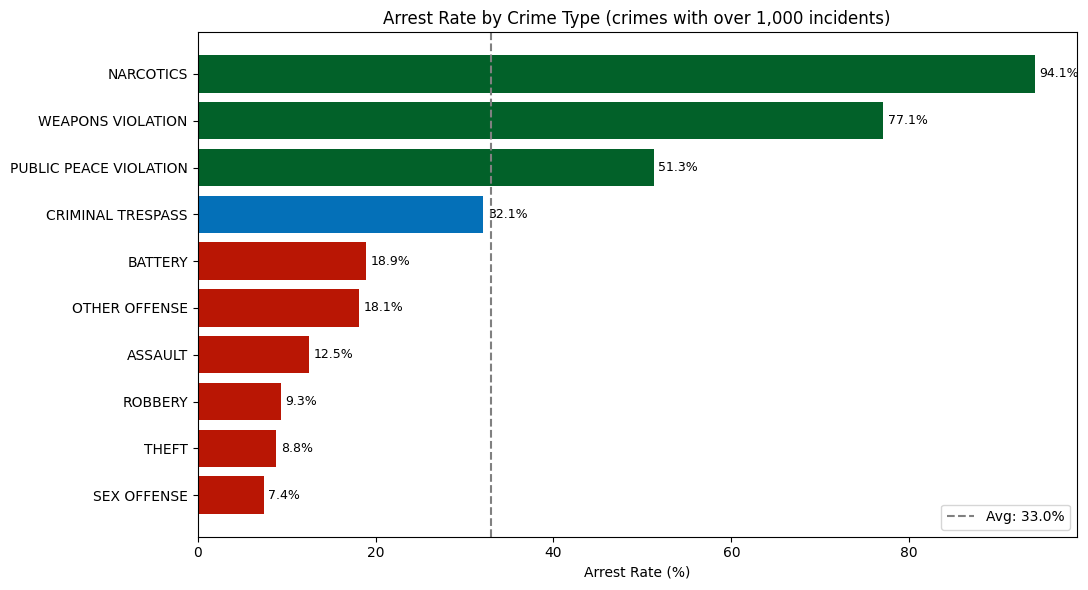

In [42]:
# Figure 4: Arrest rate by crime type (crimes with over 1,000 incidents)
arrest_data = (
    df.groupby('primary_type')
    .agg(total=('arrest', 'count'), arrests=('arrest', 'sum'))
    .reset_index()
)
arrest_data['arrest_rate'] = arrest_data['arrests'] / arrest_data['total'] * 100
arrest_data = (
    arrest_data[arrest_data['total'] > 1000]
    .sort_values('arrest_rate', ascending=False)
    .head(10)
)

# Color-code bars: green = high arrest rate, blue = moderate, red = low
colors = [
    "#026129" if r >= 50 else "#0470b8" if r >= 20 else "#B91604"
    for r in arrest_data['arrest_rate']
]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    arrest_data['primary_type'][::-1],
    arrest_data['arrest_rate'][::-1],
    color=colors[::-1]
)
for bar, val in zip(bars, arrest_data['arrest_rate'][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        fontsize=9
    )
mean_rate = arrest_data['arrest_rate'].mean()
ax.axvline(x=mean_rate, linestyle='--', color='gray', label=f'Avg: {mean_rate:.1f}%')
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate by Crime Type (crimes with over 1,000 incidents)')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_arrest_rate.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22780\3648909598.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc, x='count', y='location', palette='Blues_r', ax=ax)


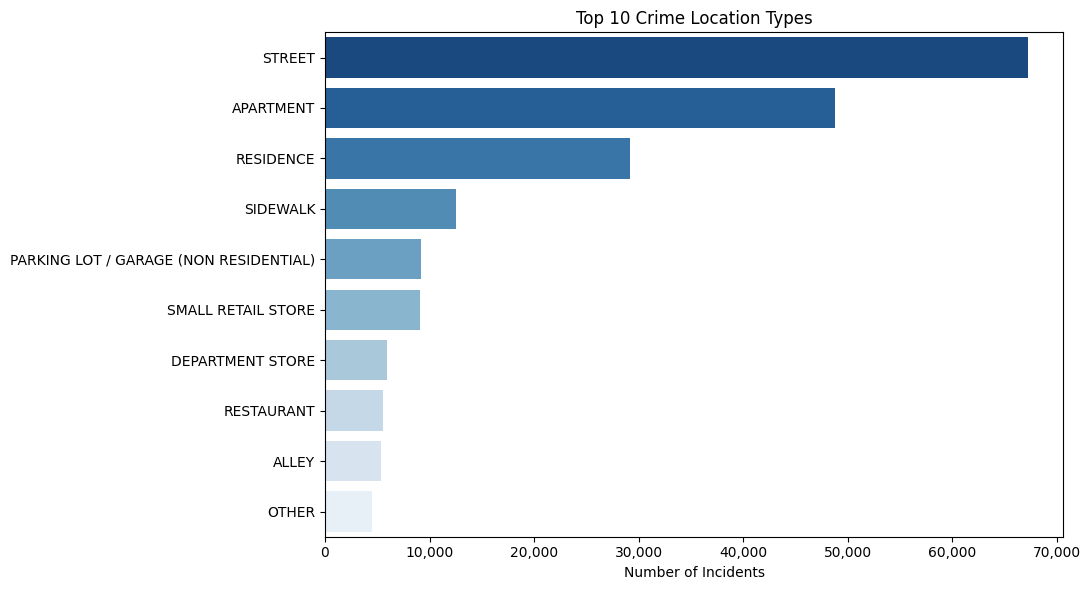

In [43]:
# Figure 5: Top 10 location types by incident count
loc = df['location_description'].value_counts().head(10).reset_index()
loc.columns = ['location', 'count']

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=loc, x='count', y='location', palette='Blues_r', ax=ax)
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('')
ax.set_title('Top 10 Crime Location Types')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig5_location_type.png', dpi=150, bbox_inches='tight')
plt.show()

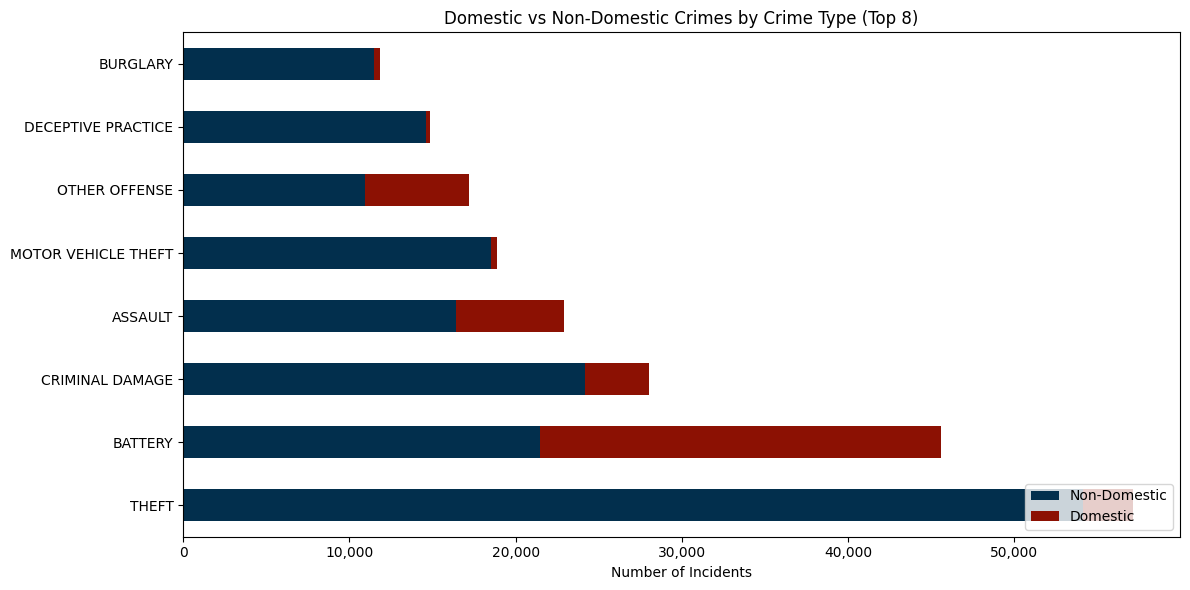

In [46]:
# Figure 6: Domestic vs non-domestic breakdown for top 8 crime types
top8 = df['primary_type'].value_counts().head(8).index.tolist()
dom_df = (
    df[df['primary_type'].isin(top8)]
    .groupby(['primary_type', 'domestic'])
    .size()
    .unstack(fill_value=0)
)
dom_df.columns = ['Non-Domestic', 'Domestic']
dom_df = dom_df.loc[top8]  # preserve volume ordering

fig, ax = plt.subplots(figsize=(12, 6))
dom_df.plot(kind='barh', stacked=True, ax=ax, color=["#022f4d", "#8c1103"])
ax.set_xlabel('Number of Incidents')
ax.set_ylabel('')
ax.set_title('Domestic vs Non-Domestic Crimes by Crime Type (Top 8)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig6_domestic.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22780\1618829691.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['day_of_week', 'hour']).size().unstack()


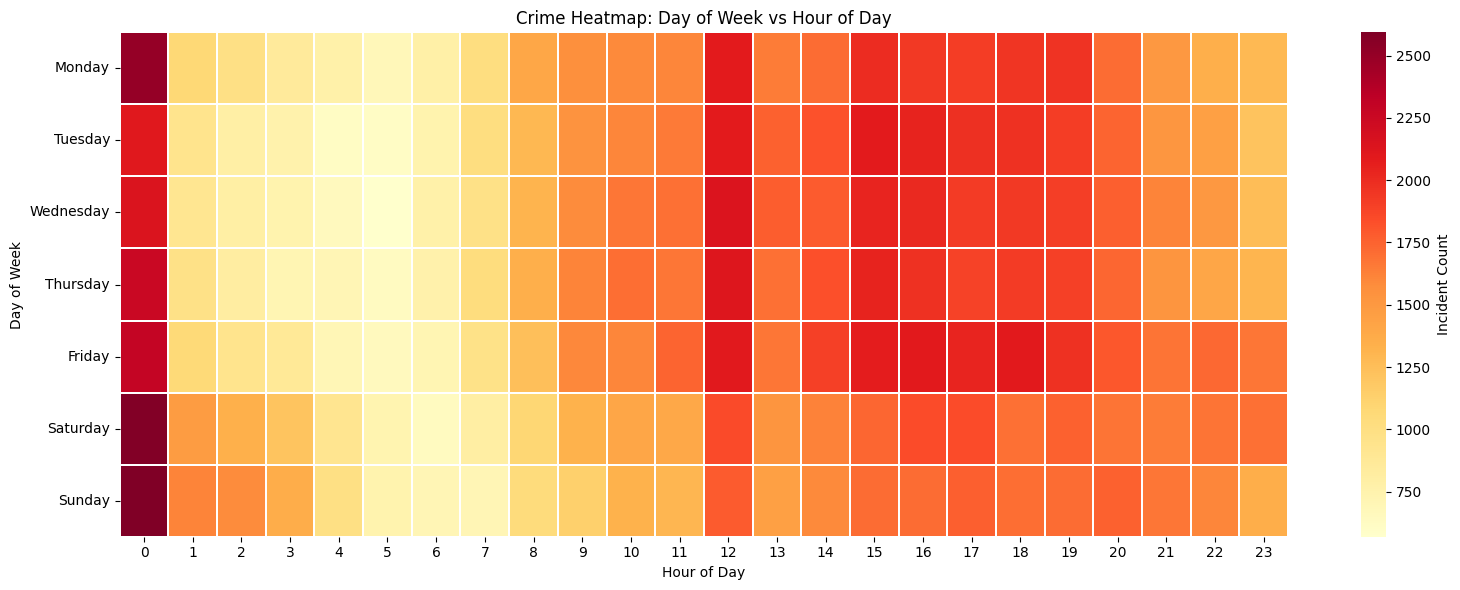

In [47]:
# Figure 7: Heatmap of crime volume by day of week and hour of day
pivot = df.groupby(['day_of_week', 'hour']).size().unstack()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.2,
    cbar_kws={'label': 'Incident Count'}
)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Crime Heatmap: Day of Week vs Hour of Day')
plt.tight_layout()
plt.savefig('fig7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()